# Fase 4 — Auditoría de las decisiones del pipeline de ML

**TFM · Sistema IoT Edge para mantenimiento predictivo · Sergio Villodas Zapata**

Este cuaderno **no es la fuente de verdad**. Los scripts de `server/analisis/` lo son: un
cuaderno guarda resultados junto al código y no registra en qué orden se ejecutaron las
celdas, así que al mes no se sabe si una cifra salió con el filtro puesto o sin él. En este
proyecto eso importa: el umbral de marcha, el corte de reintentos y la definición de los
cocientes han cambiado tres veces, y **cada cambio movió todas las cifras**.

Lo que sí hace este cuaderno es **exponer cada decisión con la evidencia que la sostiene**,
para poder revisarla. Todo lo que ejecuta viene de `pipeline.py`; no duplica lógica.

## Índice de decisiones

| # | Decisión | ¿Verificada? |
| ---: | :--- | :--- |
| 1 | Solo leer `fw-46col` en el canal de ráfaga | Sí, dos candados probados |
| 2 | Filtro de calidad con contadores **por ráfaga** | Sí, cuantificado |
| 3 | Umbral marcha/parada derivado de los datos | Sí — el valor fijo anterior era **incorrecto** |
| 4 | Reordenar los picos por **frecuencia**, no por amplitud | Sí — la definición anterior era **defectuosa** |
| 5 | Características **adimensionales** | Sí, con un coste que hubo que corregir |
| 6 | Corte de reintentos en 3 | Sí, calibrado |
| 7 | El **episodio** es la unidad de observación | Sí, es lo que permite validar |
| 8 | Qué modelo | **Revisada**: la primera elección estaba sobreajustada |

In [1]:
import sys, warnings
from pathlib import Path

# Los scripts del pipeline viven un nivel por encima. Se localizan buscando
# pipeline.py hacia arriba, para que el cuaderno funcione tanto abierto desde
# su propio directorio como desde la raiz del repositorio.
aqui = Path.cwd()
for cand in [aqui, aqui.parent, aqui / 'server' / 'analisis', aqui.parent.parent / 'server' / 'analisis']:
    if (cand / 'pipeline.py').exists():
        sys.path.insert(0, str(cand)); break
else:
    raise RuntimeError(f'no encuentro pipeline.py desde {aqui}')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pipeline as pl
from comparar_modelos import catalogo, evaluar, validacion_por_episodios
import cobertura_modos as cm

plt.rcParams.update({'figure.figsize': (11, 3.6), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 9})
print(f'pipeline cargado desde {sys.path[0]}')

pipeline cargado desde /Users/svillodas/Desktop/STUDY/TFM/server/analisis


## Los datos

Se leen del manifiesto, no recorriendo el árbol de directorios.

In [2]:
nom, tn = pl.preparar('entrenamiento')
pl.resumen('nominal (nodo A, sano)', tn)
print()
fal, tf = pl.preparar('fallo')
pl.resumen('fallo (nodo B)', tf)

  uso='entrenamiento':
    nodo-a-nevera-buena/fw-46col/2026-08-26-vibration.csv: 866 filas
    nodo-a-nevera-buena/fw-46col/2026-08-27-vibration.csv: 1002 filas


  nominal (nodo A, sano): 1868 crudas en 19.04 h
      umbral marcha/parada derivado de los datos: 0.1977 m/s2
      -    2  reinicios del nodo detectados
      calidad ok  1165 ( 62 %) | en marcha   683 ( 37 %)
      UTILES       467 ( 25 %) = 25/h  en 22 episodios de marcha
          episodio 0:   45 rafagas,   29.5 min, 15:59-16:28
          episodio 1:   77 rafagas,   66.5 min, 17:24-18:30
          episodio 2:    5 rafagas,    2.5 min, 18:34-18:37
          episodio 3:    6 rafagas,    4.0 min, 18:41-18:45
          episodio 4:    5 rafagas,    4.5 min, 18:49-18:53
          episodio 5:   22 rafagas,   22.5 min, 19:39-20:01
          episodio 6:    7 rafagas,    5.5 min, 20:05-20:10
          episodio 7:   16 rafagas,   17.0 min, 20:59-21:16
          episodio 8:   11 rafagas,    9.5 min, 21:20-21:29
          episodio 9:   15 rafagas,   23.0 min, 22:19-22:42
          episodio 10:   11 rafagas,    7.0 min, 22:45-22:52
          episodio 11:    5 rafagas,    4.0 min, 23:44-23:48
 

---
## Decisión 3 — El umbral marcha/parada

**El primer valor que se usó, 0,05 m/s², era incorrecto.** Se fijó con 1,88 h de datos. Con
19 h se ve que el grupo de parado llega hasta 0,06: el umbral caía *dentro* de ese grupo y
producía episodios espurios de una sola ráfaga.

Y el valle es **propio de cada máquina**, así que ningún valor absoluto sirve para las dos.

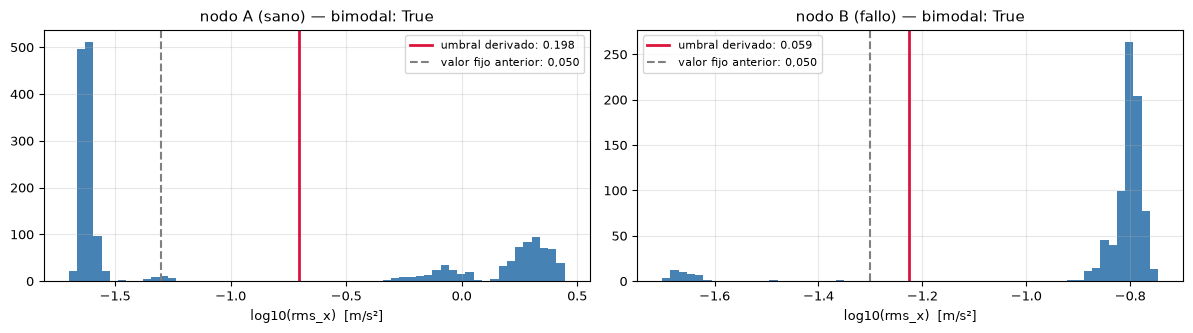

El umbral fijo de 0,05 cae DENTRO del grupo de parado del nodo A.
El valle propio de cada nodo difiere en un factor 3.


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for a, uso, nombre in [(ax[0], 'entrenamiento', 'nodo A (sano)'),
                       (ax[1], 'fallo', 'nodo B (fallo)')]:
    d = pl.limpiar(pl.cargar(uso, verboso=False))
    u, bimodal = pl.umbral_marcha(d.rms_x)
    a.hist(np.log10(d.rms_x[d.rms_x > 0]), bins=60, color='steelblue')
    a.axvline(np.log10(u), color='crimson', lw=2,
              label=f'umbral derivado: {u:.3f}')
    a.axvline(np.log10(0.05), color='gray', ls='--', lw=1.5,
              label='valor fijo anterior: 0,050')
    a.set_title(f'{nombre} — bimodal: {bimodal}')
    a.set_xlabel('log10(rms_x)  [m/s²]'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('El umbral fijo de 0,05 cae DENTRO del grupo de parado del nodo A.')
print('El valle propio de cada nodo difiere en un factor 3.')

---
## Decisión 4 — Los picos se ordenan por frecuencia, no por amplitud

El firmware los publica **ordenados por amplitud**. En el activo con fallo el armónico supera
a la fundamental por un 2 % en el 9 % de las ráfagas y le arrebata la posición de dominante:
el mismo fenómeno físico daba un cociente de 9,0 en unas ráfagas y de **0,111** en otras.

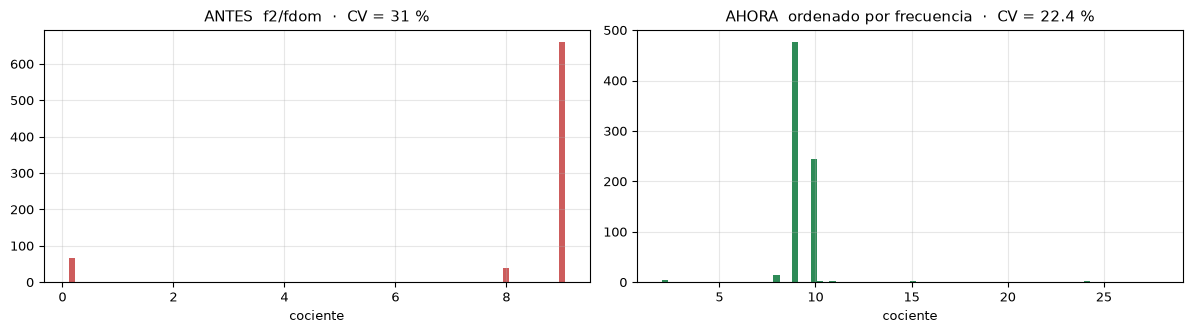

ANTES: 70 de 771 ráfagas daban un cociente < 1
       (el armonico habia adelantado a la fundamental)
AHORA: cocientes en 8.003 y 9.005  ->  armonicos 8x y 9x


In [4]:
crudo = pl.limpiar(pl.cargar('fallo', verboso=False))
u, _ = pl.umbral_marcha(crudo.rms_x)
c = crudo[crudo.rms_x > u]

# definicion ANTIGUA, por amplitud, tal como la publica el firmware
antiguo = c.f2_x / c.fdom_x
# definicion ACTUAL, reordenando por frecuencia y filtrando picos insignificantes
nuevo = pl.caracteristicas(c)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(antiguo, bins=80, color='indianred')
ax[0].set_title(f'ANTES  f2/fdom  ·  CV = {100*antiguo.std()/antiguo.mean():.0f} %')
ax[0].set_xlabel('cociente')
ax[1].hist(nuevo.r3, bins=80, color='seagreen')
ax[1].set_title(f'AHORA  ordenado por frecuencia  ·  CV = {100*nuevo.r3.std()/nuevo.r3.mean():.1f} %')
ax[1].set_xlabel('cociente')
plt.tight_layout(); plt.show()

print(f'ANTES: {(antiguo < 1).sum()} de {len(antiguo)} ráfagas daban un cociente < 1')
print(f'       (el armonico habia adelantado a la fundamental)')
print(f'AHORA: cocientes en {nuevo.r2.median():.3f} y {nuevo.r3.median():.3f}'
      f'  ->  armonicos {round(nuevo.r2.median())}x y {round(nuevo.r3.median())}x')

### La firma del fallo

Tres componentes simultáneas en múltiplos **enteros** de la frecuencia de giro. Una resonancia
estructural no produce eso.

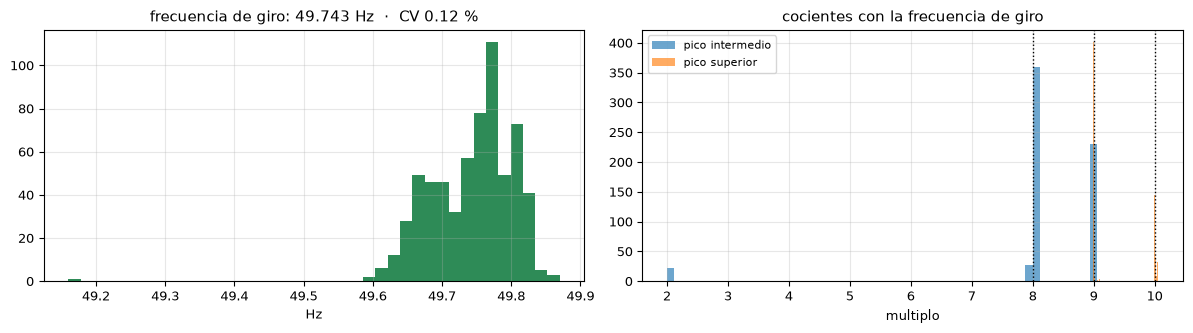

r2 cerca de 8x:  387 rafagas · valor 8.0017 · CV 0.032 % · desviacion del entero 0.021 %
r3 cerca de 9x:  413 rafagas · valor 9.0037 · CV 0.111 % · desviacion del entero 0.041 %


In [5]:
t = fal[fal.n_picos == 3]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(t.f0, bins=40, color='seagreen')
ax[0].set_title(f'frecuencia de giro: {t.f0.mean():.3f} Hz  ·  CV {100*t.f0.std()/t.f0.mean():.2f} %')
ax[0].set_xlabel('Hz')
for c_, lab in [('r2', 'pico intermedio'), ('r3', 'pico superior')]:
    ax[1].hist(t[c_], bins=60, alpha=0.65, label=lab)
for k in (8, 9, 10):
    ax[1].axvline(k, color='k', ls=':', lw=1)
ax[1].set_title('cocientes con la frecuencia de giro')
ax[1].set_xlabel('multiplo'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for c_, e in (('r2', 8), ('r3', 9)):
    v = t[c_][(t[c_] - e).abs() < 0.2]
    print(f'{c_} cerca de {e}x: {len(v):4d} rafagas · valor {v.mean():.4f} · '
          f'CV {100*v.std()/v.mean():.3f} % · desviacion del entero {100*abs(v.mean()-e)/e:.3f} %')

---
## Decisión 6 — El filtro de calidad **es parte del detector**

Éste es el hallazgo de mayor consecuencia práctica. **Los reintentos del bus I2C fabrican la
firma del fallo sobre el activo sano.** Una muestra corrupta inyecta ruido de banda ancha y
varios coeficientes del espectro superan el umbral de significación.

retries,n,espurios %,f0 mediana
0,261,0.4,49.15
1-3,206,0.5,49.17
4-5,53,7.5,49.25
6-10,48,31.2,49.16
11-20,46,93.5,20.03
>20,69,94.2,16.03


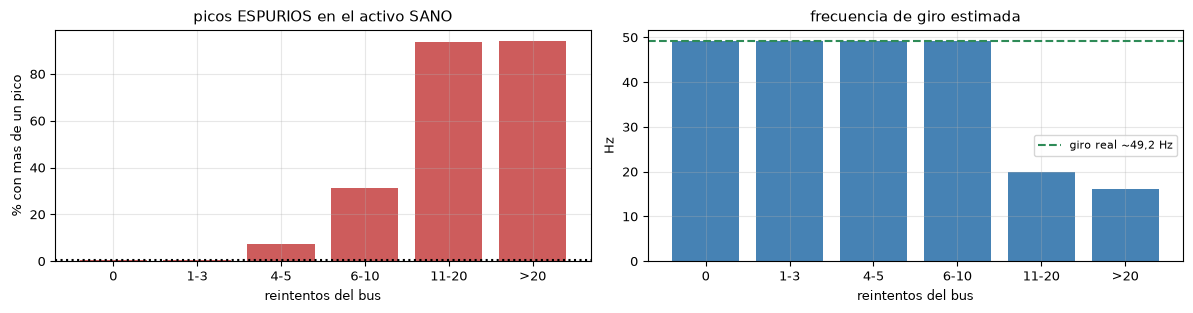

Corte elegido: retries <= 3
El nodo debe NEGARSE A JUZGAR una rafaga con mas reintentos, no juzgarla.


In [6]:
d = pl.caracteristicas(pl.limpiar(pl.cargar('entrenamiento', verboso=False)))
u, _ = pl.umbral_marcha(d.rms_x)
d = d[pl.en_marcha(d, u) & d.kurt_x.between(1, 20)]

tramos = [(0,0,'0'), (1,3,'1-3'), (4,5,'4-5'), (6,10,'6-10'), (11,20,'11-20'), (21,10**6,'>20')]
filas = []
for lo, hi, nom_ in tramos:
    g = d[(d.retries >= lo) & (d.retries <= hi)]
    filas.append({'retries': nom_, 'n': len(g),
                  'espurios %': 100*(g.n_picos > 1).mean() if len(g) else np.nan,
                  'f0 mediana': g.f0.median() if len(g) else np.nan})
tab = pd.DataFrame(filas)
display(tab.style.format({'espurios %': '{:.1f}', 'f0 mediana': '{:.2f}'}).hide(axis='index'))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].bar(tab['retries'], tab['espurios %'], color='indianred')
ax[0].axhline(0.5, color='k', ls=':'); ax[0].set_ylabel('% con mas de un pico')
ax[0].set_title('picos ESPURIOS en el activo SANO')
ax[1].bar(tab['retries'], tab['f0 mediana'], color='steelblue')
ax[1].axhline(49.2, color='seagreen', ls='--', label='giro real ~49,2 Hz')
ax[1].set_ylabel('Hz'); ax[1].set_title('frecuencia de giro estimada'); ax[1].legend(fontsize=8)
for a in ax: a.set_xlabel('reintentos del bus')
plt.tight_layout(); plt.show()

print(f'Corte elegido: retries <= {pl.MAX_RETRIES}')
print('El nodo debe NEGARSE A JUZGAR una rafaga con mas reintentos, no juzgarla.')

### ¿Y la firma del nodo B es ese mismo artefacto?

Es la pregunta que podría tumbar todo el trabajo. Se comprueba restringiendo **ambos**
conjuntos a ráfagas con **cero reintentos**.

In [7]:
def cero(d_):
    return d_[(d_.retries == 0) & (d_.cont_rejects == 0)]

a0, b0 = cero(nom), cero(fal)
print('con CERO reintentos en ambos lados:\n')
for nombre, g in [('A sano ', a0), ('B fallo', b0)]:
    rep = '  '.join(f'{k} pico(s): {(g.n_picos == k).sum():4d}' for k in (1, 2, 3))
    print(f'  {nombre} n={len(g):4d}   {rep}   f0={g.f0.median():.2f} Hz')

print('\ny la firma del nodo B con reintentos frente a sin ellos:')
for nombre, g in [('sin reintentos', b0), ('con >5      ', fal[fal.retries > 5])]:
    if len(g):
        print(f'  {nombre}: r2={g.r2.median():.3f}  r3={g.r3.median():.3f}  f0={g.f0.median():.2f}')
print('\nIdentica. Un artefacto del bus no puede producir un valor que el bus no altera.')

con CERO reintentos en ambos lados:

  A sano  n= 261   1 pico(s):  260  2 pico(s):    0  3 pico(s):    1   f0=49.15 Hz
  B fallo n= 443   1 pico(s):    0  2 pico(s):   13  3 pico(s):  430   f0=49.76 Hz

y la firma del nodo B con reintentos frente a sin ellos:
  sin reintentos: r2=8.003  r3=9.004  f0=49.76

Identica. Un artefacto del bus no puede producir un valor que el bus no altera.


---
## Decisión 7 — El episodio es la unidad de observación

Las ráfagas salen cada 30 s. Las de un mismo episodio de marcha describen la misma condición
y están fuertemente correlacionadas: **no son observaciones independientes**. La validación
correcta deja fuera un episodio completo.

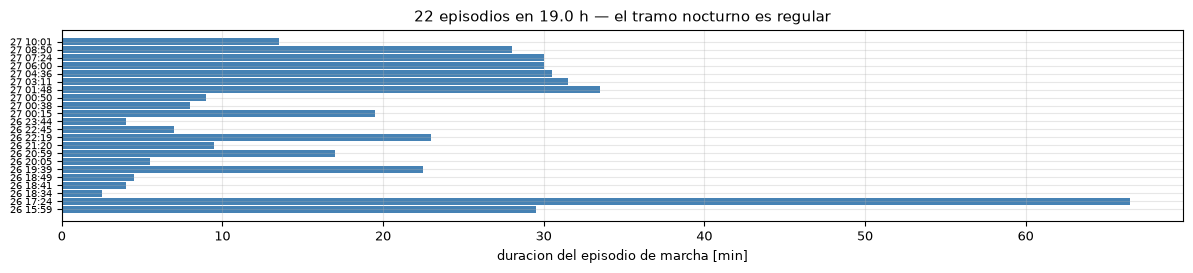

nocturnos: 9 arranques, duracion mediana 30.0 min, separados 83.8 min
El tramo de tarde da arranques cortos e irregulares: aperturas de puerta.
Esa heterogeneidad NO es un defecto: es la variabilidad que el modelo debe tolerar.


In [8]:
ep = nom.groupby('episodio').agg(n=('ts', 'size'), ini=('t', 'min'), fin=('t', 'max'))
ep['dur'] = (ep.fin - ep.ini).dt.total_seconds() / 60
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.barh(range(len(ep)), ep.dur, color='steelblue')
ax.set_yticks(range(len(ep)))
ax.set_yticklabels([t.strftime('%d %H:%M') for t in ep.ini], fontsize=7)
ax.set_xlabel('duracion del episodio de marcha [min]')
ax.set_title(f'{len(ep)} episodios en {tn["horas"]:.1f} h — el tramo nocturno es regular')
plt.tight_layout(); plt.show()

noche = ep[ep.ini.dt.hour.between(0, 9)]
print(f'nocturnos: {len(noche)} arranques, duracion mediana {noche.dur.median():.1f} min, '
      f'separados {(noche.ini.diff().dt.total_seconds()/60).median():.1f} min')
print('El tramo de tarde da arranques cortos e irregulares: aperturas de puerta.')
print('Esa heterogeneidad NO es un defecto: es la variabilidad que el modelo debe tolerar.')

---
## Decisión 8 — Qué modelo. **Aquí la primera elección estaba mal**

La primera conclusión fue *«la regla sobre `n_picos` gana a todos los modelos de ML»*. Es
**engañosa**, y conviene ver por qué.

A la regla se le dio **una** característica cuidadosamente diseñada. A los modelos de ML, las
15, incluidas varias que no separan nada y tienen mucha dispersión. Eso hunde a cualquier
modelo basado en distancias o densidades.

**Dándoles la misma característica, todos los modelos llegan al mismo resultado.**

In [9]:
cols = pl.COLUMNAS
sep = {c: abs(nom[c].median() - fal[c].median()) / (nom[c].std() + fal[c].std() + 1e-12)
       for c in cols}
orden = sorted(cols, key=lambda c: -sep[c])
print('orden de las caracteristicas por separacion medida:')
print('  ' + ' > '.join(orden[:6]) + ' > ...\n')

filas = []
for nombre, modelo in catalogo().items():
    f = {'modelo': nombre}
    for k in (1, 3, 15):
        try:
            fps, dets, n = validacion_por_episodios(modelo, nom, fal, orden[:k])
            f[f'top{k}'] = 100 * fps.max() if n else np.nan
        except Exception:
            f[f'top{k}'] = np.nan
    filas.append(f)
tab = pd.DataFrame(filas).set_index('modelo')
print('PEOR EPISODIO (% de falsos positivos) segun cuantas caracteristicas recibe:')
display(tab.style.format('{:.1f} %', na_rep='n/d'))
print('Con top1 = n_picos, TODOS convergen al mismo 8,3 %. La regla no gana a los')
print('modelos: la regla ES el modelo con una caracteristica. El merito es de la')
print('caracteristica, no del algoritmo.')

orden de las caracteristicas por separacion medida:
  n_picos > aud_b1 > aud_b0 > r3 > r2 > q3 > ...



PEOR EPISODIO (% de falsos positivos) segun cuantas caracteristicas recibe:


,top1,top3,top15
modelo,,,
Regla n_picos,8.3 %,8.3 %,8.3 %
Regla sobre r2,n/d,n/d,18.8 %
Envolvente,8.3 %,27.3 %,33.3 %
Isolation Forest,8.3 %,33.3 %,50.6 %
One-Class SVM,8.3 %,24.4 %,71.4 %
LOF (novelty),8.3 %,50.0 %,33.3 %
Elliptic Envelope,8.3 %,27.3 %,25.0 %


Con top1 = n_picos, TODOS convergen al mismo 8,3 %. La regla no gana a los
modelos: la regla ES el modelo con una caracteristica. El merito es de la
caracteristica, no del algoritmo.


### Y ahí está el problema: **el modelo debe generalizar**

Esa característica se eligió **sabiendo cuál era el fallo**. Un detector construido así no
generaliza a fallos que no se han visto — y eso es justamente lo que se le pide a un detector
de anomalías, que por definición no conoce los fallos de antemano.

Se comprueba perturbando el conjunto sano en las direcciones de fallos típicos.
**Los datos son sintéticos y no son evidencia**: localizan puntos ciegos.

In [10]:
Xn = nom[cols].values
filas = []
for nombre, modelo in catalogo().items():
    f = {'modelo': nombre}
    for m in cm.MODOS:
        f[m] = 100 * evaluar(modelo, Xn, Xn[:0], cm.perturbar(nom, m)[cols].values, cols)[1]
    f['FALLO REAL'] = 100 * evaluar(modelo, Xn, Xn[:0], fal[cols].values, cols)[1]
    filas.append(f)
tab = pd.DataFrame(filas).set_index('modelo')
print('% de rafagas perturbadas que cada modelo marcaria (SINTETICO, no evidencia):')
display(tab.style.format('{:.0f} %').background_gradient(cmap='RdYlGn', vmin=0, vmax=100))
print('La regla es CIEGA a casi todo lo que no anade componentes espectrales.')
print('La obstruccion de ventilacion no altera la vibracion: solo la ve el canal termico.')

% de rafagas perturbadas que cada modelo marcaria (SINTETICO, no evidencia):


,holgura,rodamiento,roce,desequilibrio,obstruccion,FALLO REAL
modelo,,,,,,
Regla n_picos,100 %,0 %,0 %,0 %,0 %,100 %
Regla sobre r2,0 %,5 %,5 %,5 %,5 %,97 %
Envolvente,100 %,100 %,100 %,95 %,31 %,100 %
Isolation Forest,100 %,100 %,100 %,7 %,9 %,100 %
One-Class SVM,100 %,100 %,100 %,78 %,79 %,100 %
LOF (novelty),100 %,100 %,100 %,79 %,80 %,100 %
Elliptic Envelope,100 %,100 %,100 %,98 %,13 %,100 %


La regla es CIEGA a casi todo lo que no anade componentes espectrales.
La obstruccion de ventilacion no altera la vibracion: solo la ve el canal termico.


### El compromiso, y la elección revisada

La envolvente robusta cubre las cinco direcciones. Su «peor episodio» del 25 % suena mal, pero
hay que mirar de qué está hecho.

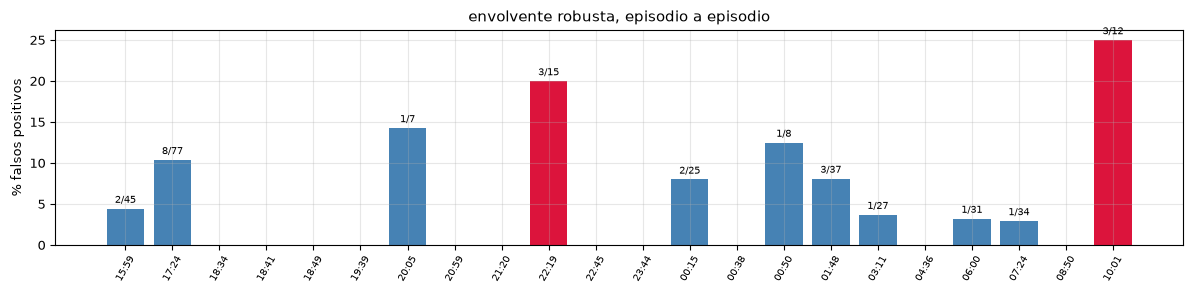

media simple        5.1 %
peor episodio      25.0 %  <- son 3 rafagas de 12, episodio corto
PONDERADO por rafagas   5.6 %  <- lo que se veria en operacion
episodios con 0 %: 11 de 22


In [11]:
mod = catalogo()['Elliptic Envelope']
filas = []
for e in sorted(nom.episodio.unique()):
    tr, te = nom[nom.episodio != e], nom[nom.episodio == e]
    if len(tr) < 20 or len(te) < 3:
        continue
    fp, _ = evaluar(mod, tr[cols].values, te[cols].values, fal[cols].values, cols)
    filas.append({'ep': e, 'n': len(te), 'fp': 100*fp,
                  'rafagas': int(round(fp*len(te))), 'hora': te.t.min().strftime('%H:%M')})
tab = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(12, 3.0))
col = ['crimson' if x > 15 else 'steelblue' for x in tab.fp]
ax.bar(range(len(tab)), tab.fp, color=col)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.hora, rotation=60, fontsize=7)
for i, r in tab.iterrows():
    if r.fp > 0:
        ax.text(i, r.fp + 0.7, f'{r.rafagas}/{r.n}', ha='center', fontsize=7)
ax.set_ylabel('% falsos positivos'); ax.set_title('envolvente robusta, episodio a episodio')
plt.tight_layout(); plt.show()

pond = (tab.fp * tab.n).sum() / tab.n.sum()
print(f'media simple      {tab.fp.mean():5.1f} %')
print(f'peor episodio     {tab.fp.max():5.1f} %  <- son {tab.loc[tab.fp.idxmax(),"rafagas"]} rafagas de '
      f'{tab.loc[tab.fp.idxmax(),"n"]}, episodio corto')
print(f'PONDERADO por rafagas {pond:5.1f} %  <- lo que se veria en operacion')
print(f'episodios con 0 %: {(tab.fp == 0).sum()} de {len(tab)}')

---
## Conclusión de la auditoría

**La elección revisada: la envolvente robusta como detector principal**, con la regla sobre
`n_picos` como confirmación de alta confianza.

| | Envolvente robusta | Regla `n_picos` |
| :--- | :--- | :--- |
| Falsos positivos, ponderado | 5,6 % | 0,5 % |
| Peor episodio | 25 % (3 de 12 ráfagas) | 8,3 % |
| Direcciones de fallo cubiertas | **5 de 5** | 1 de 5 |
| ¿Generaliza a fallos no vistos? | **Sí** | No |
| ¿Cabe en el ESP32? | Sí, forma cuadrática | Sí, una comparación |

El motivo del cambio es el que se ha expuesto: **el 8,3 % de la regla se mide contra el único
fallo para el que se diseñó**. Su ventaja no sobrevive a un fallo distinto, y un detector de
anomalías tiene por objeto precisamente los fallos que no se conocen.

Ambas se embarcan, con significados distintos:
- **Envolvente fuera del intervalo** → «algo ha cambiado», detector principal
- **`n_picos` > 1** → «fallo de naturaleza armónica», alta confianza

Y ambas con **histéresis**: N ráfagas anómalas consecutivas antes de notificar.

### Lo que esta auditoría no puede resolver

1. **Los dos activos son máquinas distintas.** Las características adimensionales acotan ese
   sesgo, no lo eliminan. Solo un fallo inducido sobre el activo de referencia lo elimina.
2. **Un solo modo de fallo real.** Las cinco direcciones del análisis de cobertura son
   sintéticas.
3. **El lado del fallo tiene 2 episodios.** La validación por episodios se aplica al lado
   nominal.